# Data Transformation — choosing the optimal expression of each variable

This notebook selects, for every variable in `data_062026.xlsx` (sheets **target** and
**regressors**), the *expression* (levels / yearly difference / yearly growth) and the
*mathematical transformation* (none / log / sqrt, chosen via a Box-Cox parameter) that best
relate it to the NPL target.

Pipeline (one step per numbered section):

1. Read the **target** and **regressors** sheets of `data_062026.xlsx`.
2. Build the expression functions `yearly_difference()` and `yearly_growth()` (plus the
   identity *levels*).
3. For every regressor, express it in the three forms and compute the Spearman correlation
   (post-2002) against `npl_total` **in levels**, plotting the three forms alongside the target.
4. Repeat, correlating every regressor against `npl_total` expressed as **yearly difference**
   and **yearly growth**.
5. Compare the three expressions of `npl_total` by their aggregate Spearman correlation with
   all regressors and pick the strongest.
6. Fix the optimal expression of `npl_total`; express every other variable in the form that
   maximises its Spearman correlation with that chosen expression of `npl_total`.
7. Estimate a Box-Cox parameter per variable to decide a mathematical transformation
   (`lambda≈0`→log, `lambda≈0.5`→sqrt, `lambda≈1`→none).
8. Implement the mathematical transformation functions
   ([fpp2 §3.2](https://otexts.com/fpp2/transformations.html)) and apply them.
9. Write `transformed_data_{date}.xlsx` with a **data** sheet (transformed series) and a
   **transformations** metadata sheet (chosen expression + mathematical transformation per
   variable).

> **Note.** To keep the committed notebook fast and reviewable it runs in `SAMPLE_MODE`
> (a handful of representative variables). Set `SAMPLE_MODE = False` to run the full pipeline
> over all 175 regressors and every target column.

## 0 · Imports & configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, boxcox, zscore

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

# --- Configuration ---------------------------------------------------------
DATE_TAG    = "062026"                       # matches data_062026.xlsx
INPUT_NAME  = f"data_{DATE_TAG}.xlsx"
OUTPUT_NAME = f"transformed_data_{DATE_TAG}.xlsx"

PERIODS_PER_YEAR = 12          # monthly data -> a "year" is 12 observations
CORR_START       = "2003-01-01" # correlations start AFTER the Colombian crisis (ended 2002)
MIN_OBS          = 24           # minimum overlapping points to trust a correlation

REFERENCE = "npl_total"        # the target everything is compared against

# Sample mode keeps the committed run small and tested. Flip to False for the full dataset.
SAMPLE_MODE = True
SAMPLE_REGRESSORS = ["tipocambio_usd_finmes", "dtf_90d", "inflacion_total",
                     "reservas_intern_net", "brent", "vix"]
SAMPLE_TARGETS    = ["npl_total", "npl_comercial", "npl_consumo"]  # incl. the reference

# Locate the input workbook regardless of the working directory.
def _find(name):
    for p in [Path("data")/name, Path("../data")/name, Path(name)]:
        if p.exists():
            return p
    raise FileNotFoundError(name)

INPUT_PATH  = _find(INPUT_NAME)
OUTPUT_PATH = INPUT_PATH.parent / OUTPUT_NAME
print("Input :", INPUT_PATH.resolve())
print("Output:", OUTPUT_PATH.resolve())

Input : /home/user/npl_forecasting/data/data_062026.xlsx
Output: /home/user/npl_forecasting/data/transformed_data_062026.xlsx


## 1 · Read the `target` and `regressors` sheets

Both sheets share a monthly `date` column, which we parse and use as the index.

In [2]:
target_raw     = pd.read_excel(INPUT_PATH, sheet_name="target",     parse_dates=["date"]).set_index("date").sort_index()
regressors_raw = pd.read_excel(INPUT_PATH, sheet_name="regressors", parse_dates=["date"]).set_index("date").sort_index()

# Make sure everything is numeric.
target_raw     = target_raw.apply(pd.to_numeric, errors="coerce")
regressors_raw = regressors_raw.apply(pd.to_numeric, errors="coerce")

print("target    :", target_raw.shape, "| cols:", list(target_raw.columns[:6]), "...")
print("regressors:", regressors_raw.shape)
print("\nnpl_total range:", target_raw[REFERENCE].first_valid_index(), "->",
      target_raw[REFERENCE].last_valid_index())
target_raw[[REFERENCE]].dropna().tail()

target    : (430, 18) | cols: ['bruta_comercial', 'bruta_consumo', 'bruta_hipotecaria', 'bruta_microcredito', 'bruta_total', 'bruta_totalsinmicro'] ...
regressors: (432, 175)

npl_total range: 1994-12-01 00:00:00 -> 2026-03-01 00:00:00


,npl_total
date,
2025-11-01,3.990305
2025-12-01,3.832119
2026-01-01,3.897149
2026-02-01,3.870082
2026-03-01,3.805217


In [3]:
# Select the working universe (sample vs. full).
if SAMPLE_MODE:
    regressor_cols = [c for c in SAMPLE_REGRESSORS if c in regressors_raw.columns]
    target_cols    = [c for c in SAMPLE_TARGETS    if c in target_raw.columns]
else:
    regressor_cols = list(regressors_raw.columns)
    target_cols    = list(target_raw.columns)

# Every column that will be transformed (the reference target is included once).
all_vars = {c: target_raw[c]     for c in target_cols}
all_vars.update({c: regressors_raw[c] for c in regressor_cols if c not in all_vars})

npl_level = target_raw[REFERENCE].copy()   # reference target, in levels
print(f"Processing {len(all_vars)} variables "
      f"({len(target_cols)} target cols + {len([c for c in regressor_cols if c not in target_cols])} regressors).")
print("Variables:", list(all_vars))

Processing 9 variables (3 target cols + 6 regressors).
Variables: ['npl_total', 'npl_comercial', 'npl_consumo', 'tipocambio_usd_finmes', 'dtf_90d', 'inflacion_total', 'reservas_intern_net', 'brent', 'vix']


## 2 · Expression functions

Each variable can be expressed in one of three forms. With monthly data a *year* is
`PERIODS_PER_YEAR = 12` observations.

* **levels** — the series as-is.
* **yearly_difference** — `x_t − x_{t−12}`.
* **yearly_growth** — `100 · (x_t / x_{t−12} − 1)`, the year-on-year percentage change.

In [4]:
def levels(s: pd.Series) -> pd.Series:
    "Identity expression: return the series unchanged."
    return s.copy()

def yearly_difference(s: pd.Series, periods: int = PERIODS_PER_YEAR) -> pd.Series:
    "Year-on-year difference: x_t - x_{t-periods}."
    return s - s.shift(periods)

def yearly_growth(s: pd.Series, periods: int = PERIODS_PER_YEAR) -> pd.Series:
    "Year-on-year percentage growth: 100 * (x_t / x_{t-periods} - 1)."
    return s.pct_change(periods) * 100.0

# Registry mapping an expression name to its function.
EXPRESSIONS = {
    "levels":            levels,
    "yearly_difference": yearly_difference,
    "yearly_growth":     yearly_growth,
}

def express(s: pd.Series, name: str) -> pd.Series:
    return EXPRESSIONS[name](s)

# Quick sanity check on npl_total.
_demo = pd.DataFrame({name: express(npl_level, name) for name in EXPRESSIONS}).dropna()
_demo.tail()

,levels,yearly_difference,yearly_growth
date,,,
2025-11-01,3.990305,-1.030876,-20.530551
2025-12-01,3.832119,-0.871261,-18.524144
2026-01-01,3.897149,-0.834651,-17.639181
2026-02-01,3.870082,-0.816933,-17.429705
2026-03-01,3.805217,-0.830546,-17.916052


## 3 · Spearman correlation helper (post-2002)

`spearman_corr` aligns two series, keeps only overlapping non-missing observations dated on or
after `CORR_START`, and returns the Spearman rank correlation (or `NaN` when there is too little
overlap or no variation).

In [5]:
def spearman_corr(x: pd.Series, y: pd.Series,
                  start: str = CORR_START, min_obs: int = MIN_OBS) -> float:
    "Spearman correlation between x and y on their common post-`start` support."
    pair = pd.concat([x, y], axis=1, keys=["x", "y"]).loc[start:].dropna()
    if len(pair) < min_obs or pair["x"].nunique() < 2 or pair["y"].nunique() < 2:
        return np.nan
    rho, _ = spearmanr(pair["x"], pair["y"])
    return rho

### 3a · Per-regressor: three expressions vs. `npl_total` (levels)

For every regressor we compute the Spearman correlation of each of its three expressions
against `npl_total` **in levels**, and (for the sample) plot the three expressions next to the
target. Series are z-scored *for plotting only* so different scales are comparable.

In [6]:
def correlations_against(npl_series: pd.Series, variables: dict) -> pd.DataFrame:
    "For each variable, Spearman corr of each expression vs. the given npl expression."
    rows = {}
    for name, s in variables.items():
        rows[name] = {expr: spearman_corr(express(s, expr), npl_series)
                      for expr in EXPRESSIONS}
    return pd.DataFrame(rows).T[list(EXPRESSIONS)]

# Regressor-only universe (exclude the reference target itself from the comparison set).
regressor_vars = {k: v for k, v in all_vars.items() if k != REFERENCE}

corr_vs_levels = correlations_against(express(npl_level, "levels"), regressor_vars)
print("Spearman corr of each expression vs. npl_total (levels):")
corr_vs_levels.round(3)

Spearman corr of each expression vs. npl_total (levels):


,levels,yearly_difference,yearly_growth
npl_comercial,0.814,0.180,0.167
npl_consumo,0.721,0.037,0.050
tipocambio_usd_finmes,0.550,0.012,0.017
dtf_90d,0.240,-0.402,-0.386
inflacion_total,0.216,-0.346,-0.348
reservas_intern_net,0.249,-0.235,-0.371
brent,-0.344,-0.046,0.014
vix,0.168,-0.068,-0.056


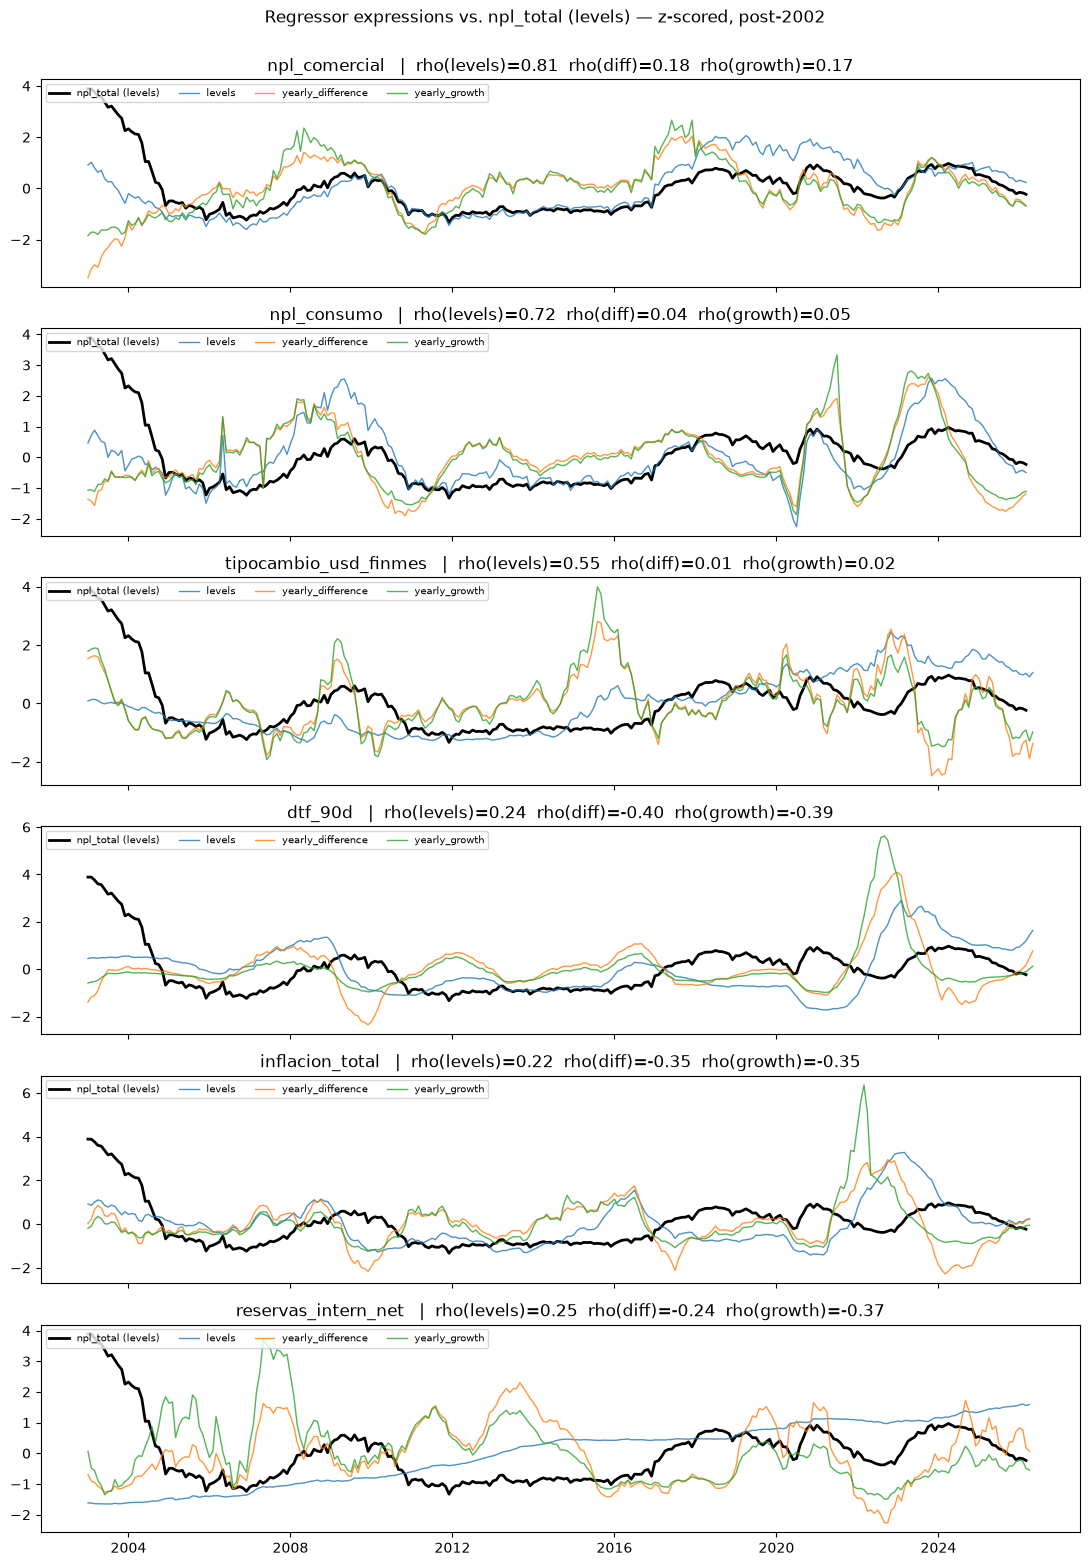

In [7]:
# Visual check for the sample regressors: 3 expressions + npl_total (levels), z-scored.
plot_vars = list(regressor_vars)[:6]
npl_z = pd.Series(zscore(express(npl_level, "levels").loc[CORR_START:].dropna()),
                  index=express(npl_level, "levels").loc[CORR_START:].dropna().index)

fig, axes = plt.subplots(len(plot_vars), 1, figsize=(11, 2.6 * len(plot_vars)), sharex=True)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, plot_vars):
    ax.plot(npl_z.index, npl_z.values, color="black", lw=2, label="npl_total (levels)")
    for expr in EXPRESSIONS:
        e = express(regressor_vars[name], expr).loc[CORR_START:].dropna()
        if len(e) > MIN_OBS and e.nunique() > 1:
            ax.plot(e.index, zscore(e), lw=1, alpha=0.8, label=expr)
    rho = corr_vs_levels.loc[name]
    ax.set_title(f"{name}   |  rho(levels)={rho['levels']:.2f}  "
                 f"rho(diff)={rho['yearly_difference']:.2f}  rho(growth)={rho['yearly_growth']:.2f}")
    ax.legend(loc="upper left", fontsize=7, ncol=4)
fig.suptitle("Regressor expressions vs. npl_total (levels) — z-scored, post-2002", y=1.001)
fig.tight_layout()
plt.show()

## 4 · Repeat against `npl_total` as yearly difference and yearly growth

The same correlation table, now using `npl_total` expressed as a yearly difference and as a
yearly growth.

In [8]:
npl_expressions = {expr: express(npl_level, expr) for expr in EXPRESSIONS}

corr_tables = {expr: correlations_against(npl_expressions[expr], regressor_vars)
               for expr in EXPRESSIONS}

for expr in EXPRESSIONS:
    print(f"\n=== Spearman corr of each regressor expression vs. npl_total [{expr}] ===")
    print(corr_tables[expr].round(3))


=== Spearman corr of each regressor expression vs. npl_total [levels] ===
                       levels  yearly_difference  yearly_growth
npl_comercial           0.814              0.180          0.167
npl_consumo             0.721              0.037          0.050
tipocambio_usd_finmes   0.550              0.012          0.017
dtf_90d                 0.240             -0.402         -0.386
inflacion_total         0.216             -0.346         -0.348
reservas_intern_net     0.249             -0.235         -0.371
brent                  -0.344             -0.046          0.014
vix                     0.168             -0.068         -0.056

=== Spearman corr of each regressor expression vs. npl_total [yearly_difference] ===
                       levels  yearly_difference  yearly_growth
npl_comercial           0.242              0.894          0.900
npl_consumo             0.525              0.842          0.844
tipocambio_usd_finmes   0.022             -0.046         -0.026
dtf_90d

## 5 · Which expression of `npl_total` correlates best, overall?

For each expression of `npl_total` we take, per regressor, the strongest correlation across the
regressor's three forms (`max |rho|`) and aggregate it across all regressors. The expression of
`npl_total` with the largest aggregate (and average) wins.

In [9]:
summary_rows = []
for expr, tbl in corr_tables.items():
    best_per_regressor = tbl.abs().max(axis=1)        # best form for each regressor
    summary_rows.append({
        "npl_expression":  expr,
        "n_regressors":    int(best_per_regressor.notna().sum()),
        "aggregate_|rho|": best_per_regressor.sum(),
        "mean_|rho|":      best_per_regressor.mean(),
    })
comparison = pd.DataFrame(summary_rows).set_index("npl_expression")
comparison = comparison.sort_values("aggregate_|rho|", ascending=False)

best_npl_expr = comparison["aggregate_|rho|"].idxmax()
print("Aggregate Spearman strength by npl_total expression:")
print(comparison.round(3))
print(f"\n>>> Optimal expression of npl_total: '{best_npl_expr}'")

Aggregate Spearman strength by npl_total expression:
                   n_regressors  aggregate_|rho|  mean_|rho|
npl_expression                                              
levels                        8            3.716       0.465
yearly_difference             8            2.628       0.328
yearly_growth                 8            2.622       0.328

>>> Optimal expression of npl_total: 'levels'


## 6 · Fix `npl_total`'s expression, then choose each variable's best form

With the optimal expression of `npl_total` chosen, every other variable is assigned the
expression that maximises its (absolute) Spearman correlation with that chosen expression of
`npl_total`. `npl_total` itself keeps the optimal expression from §5.

In [10]:
best_corr_table = corr_tables[best_npl_expr]

chosen_expression = {}
chosen_corr = {}
for name in regressor_vars:
    row = best_corr_table.loc[name]
    if row.abs().notna().any():
        expr = row.abs().idxmax()
        chosen_expression[name] = expr
        chosen_corr[name] = row[expr]
    else:                                  # no usable correlation -> keep levels
        chosen_expression[name] = "levels"
        chosen_corr[name] = np.nan

# The reference target uses the optimal expression found in section 5.
chosen_expression[REFERENCE] = best_npl_expr
chosen_corr[REFERENCE] = np.nan

expr_choice = pd.DataFrame({
    "chosen_expression": pd.Series(chosen_expression),
    "spearman_vs_npl":   pd.Series(chosen_corr),
}).loc[list(all_vars)]
print(f"Each variable expressed to best match npl_total [{best_npl_expr}]:")
expr_choice.round(3)

Each variable expressed to best match npl_total [levels]:


,chosen_expression,spearman_vs_npl
npl_total,levels,NaN
npl_comercial,levels,0.814
npl_consumo,levels,0.721
tipocambio_usd_finmes,levels,0.550
dtf_90d,yearly_difference,-0.402
inflacion_total,yearly_growth,-0.348
reservas_intern_net,yearly_growth,-0.371
brent,levels,-0.344
vix,levels,0.168


## 7 · Box-Cox parameter → mathematical transformation

We estimate a Box-Cox `lambda` on each variable's **positive level** series and snap it to the
nearest of `{0, 0.5, 1}` to pick a mathematical transformation:

| lambda | transform |
|---|---|
| 0   | log |
| 0.5 | sqrt |
| 1   | none |

Box-Cox needs strictly positive data; variables containing non-positive values fall back to
`none`.

In [11]:
LAMBDA_TO_TRANSFORM = {0.0: "log", 0.5: "sqrt", 1.0: "none"}
LAMBDA_CANDIDATES = np.array([0.0, 0.5, 1.0])

def estimate_boxcox(level: pd.Series):
    "Return (raw_lambda, snapped_lambda, transform_name) for a level series."
    s = level.dropna()
    if len(s) < MIN_OBS or (s <= 0).any() or s.nunique() < 2:
        return (np.nan, 1.0, "none")          # cannot Box-Cox -> no transform
    _, lam = boxcox(s.values)
    snapped = float(LAMBDA_CANDIDATES[np.argmin(np.abs(LAMBDA_CANDIDATES - lam))])
    return (float(lam), snapped, LAMBDA_TO_TRANSFORM[snapped])

boxcox_rows = {}
for name, s in all_vars.items():
    lam, snapped, tname = estimate_boxcox(s)
    boxcox_rows[name] = {"boxcox_lambda": lam, "snapped_lambda": snapped,
                         "math_transformation": tname}
boxcox_choice = pd.DataFrame(boxcox_rows).T.loc[list(all_vars)]
boxcox_choice

,boxcox_lambda,snapped_lambda,math_transformation
npl_total,-0.892878,0.0,log
npl_comercial,-0.49238,0.0,log
npl_consumo,-1.337694,0.0,log
tipocambio_usd_finmes,0.619144,0.5,sqrt
dtf_90d,-0.170574,0.0,log
inflacion_total,-0.179095,0.0,log
reservas_intern_net,0.063444,0.0,log
brent,0.252844,0.5,sqrt
vix,-0.732578,0.0,log


## 8 · Mathematical transformation functions and application

Following [fpp2 §3.2](https://otexts.com/fpp2/transformations.html) we implement the log and
square-root transforms (and the general Box-Cox for completeness), then build each final series
as `expression( math_transform( level ) )` — i.e. stabilise the variance first, then express.

In [12]:
def log_transformation(s: pd.Series) -> pd.Series:
    "Natural log (Box-Cox lambda = 0)."
    return np.log(s)

def sqrt_transformation(s: pd.Series) -> pd.Series:
    "Square root (Box-Cox lambda = 0.5)."
    return np.sqrt(s)

def boxcox_transformation(s: pd.Series, lam: float) -> pd.Series:
    "General Box-Cox transform with parameter lam (fpp2 §3.2)."
    if lam == 0:
        return np.log(s)
    return (np.sign(s) * np.abs(s) ** lam - 1) / lam

MATH_TRANSFORMS = {
    "none": lambda s: s.copy(),
    "log":  log_transformation,
    "sqrt": sqrt_transformation,
}

def build_series(level: pd.Series, math_name: str, expr_name: str) -> pd.Series:
    "Apply the mathematical transform to the level, then the chosen expression."
    return express(MATH_TRANSFORMS[math_name](level), expr_name)

transformed = {}
metadata_rows = {}
for name, level in all_vars.items():
    expr_name = chosen_expression[name]
    math_name = boxcox_choice.loc[name, "math_transformation"]
    transformed[name] = build_series(level, math_name, expr_name)
    metadata_rows[name] = {
        "variable":            name,
        "source_sheet":        "target" if name in target_cols else "regressors",
        "is_reference_target": name == REFERENCE,
        "expression":          expr_name,
        "mathematical_transformation": math_name,
        "boxcox_lambda":       boxcox_choice.loc[name, "boxcox_lambda"],
        "spearman_vs_npl_total": chosen_corr[name],
    }

transformed_df = pd.DataFrame(transformed).sort_index()
metadata_df = pd.DataFrame(metadata_rows).T.loc[list(all_vars)].reset_index(drop=True)

print("Transformed data (tail):")
print(transformed_df.dropna(how="all").tail())
print("\nMetadata:")
metadata_df

Transformed data (tail):
            npl_total  npl_comercial  npl_consumo  tipocambio_usd_finmes   dtf_90d  inflacion_total  reservas_intern_net      brent       vix
date                                                                                                                                         
2026-01-01   1.360245       1.194225     1.622749              60.809868 -0.023040         1.488605             0.576677   8.500000  2.858766
2026-02-01   1.353276       1.182034     1.629633              60.602145  0.012676         0.113716             0.549293   8.445117  2.988708
2026-03-01   1.336373       1.168449     1.613231              60.969747  0.047761         5.427486             0.382046  11.255665  3.228826
2026-04-01        NaN            NaN          NaN              60.112727  0.125131         5.851210             0.345726  11.146300  2.826722
2026-05-01        NaN            NaN          NaN              61.155539  0.200244              NaN                  NaN   

,variable,source_sheet,is_reference_target,expression,mathematical_transformation,boxcox_lambda,spearman_vs_npl_total
0,npl_total,target,True,levels,log,-0.892878,NaN
1,npl_comercial,target,False,levels,log,-0.49238,0.813648
2,npl_consumo,target,False,levels,log,-1.337694,0.720504
3,tipocambio_usd_finmes,regressors,False,levels,sqrt,0.619144,0.549754
4,dtf_90d,regressors,False,yearly_difference,log,-0.170574,-0.402117
5,inflacion_total,regressors,False,yearly_growth,log,-0.179095,-0.347681
6,reservas_intern_net,regressors,False,yearly_growth,log,0.063444,-0.370848
7,brent,regressors,False,levels,sqrt,0.252844,-0.343608
8,vix,regressors,False,levels,log,-0.732578,0.168034


## 9 · Write `transformed_data_{date}.xlsx`

Two sheets: **data** (transformed series, indexed by date) and **transformations** (the chosen
expression and mathematical transformation per variable).

In [13]:
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    transformed_df.to_excel(writer, sheet_name="data", index=True, index_label="date")
    metadata_df.to_excel(writer, sheet_name="transformations", index=False)

print(f"Wrote {OUTPUT_PATH.resolve()}")
print(f"  data sheet           : {transformed_df.shape[0]} rows x {transformed_df.shape[1]} variables")
print(f"  transformations sheet: {metadata_df.shape[0]} variables")
metadata_df[["variable", "expression", "mathematical_transformation"]]

Wrote /home/user/npl_forecasting/data/transformed_data_062026.xlsx
  data sheet           : 432 rows x 9 variables
  transformations sheet: 9 variables


,variable,expression,mathematical_transformation
0,npl_total,levels,log
1,npl_comercial,levels,log
2,npl_consumo,levels,log
3,tipocambio_usd_finmes,levels,sqrt
4,dtf_90d,yearly_difference,log
5,inflacion_total,yearly_growth,log
6,reservas_intern_net,yearly_growth,log
7,brent,levels,sqrt
8,vix,levels,log
